In [ ]:
import pandas as pd
import seaborn as sns

from cdc_ml.config import (
    CUSTOMER_CLASS_PROCESSED,
    FEATURE_ABLATIONS_RESULTS,
    POLLS_PROCESSED,
    PREFERENCE_PROCESSED,
    REPORTS_FIGURE,
)

from cdc_ml.features.build_features import (
    build_features,
    get_whale_users,
)

from cdc_ml.modeling.config import (
    CHOSEN_FEATURES,
    FEATS_ABL_LIST,
)

from cdc_ml.modeling.crossval import (
    make_holdout_split,
    repeated_cv_pr_auc,
)

from cdc_ml.modeling.evaluation import (
    adversarial_validation,
    compare_feature_sets,
    paired_t,
    per_customer_at_budget,
    pr_auc_ci_by_user,
)

from cdc_ml.modeling.model import randSearch
from cdc_ml.modeling.train import train

from cdc_ml.plots import (
    bootstrapped_gain_curve,
    plot_calibration_by_volume,
)


2026-06-06 14:41:01.662 | INFO     | cdc_ml.config:<module>:12 - PROJ_ROOT path is: C:\Users\zhiju\Desktop\cdc_ml


In [2]:
df = pd.read_parquet(POLLS_PROCESSED)
df_pref = pd.read_parquet(PREFERENCE_PROCESSED)
df_class = pd.read_parquet(CUSTOMER_CLASS_PROCESSED)

In [3]:
df_pref.loc[(df_pref["id"]==44)]

,id,username,day_of_week,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040,mon,tues,wed,thurs,fri,sat,sun
1106,44,kim,4,2025-12-05 00:00:00+08:00,2025-12-05 23:00:00+08:00,2025-12-05 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1107,44,kim,4,2025-12-12 00:00:00+08:00,2025-12-12 23:00:00+08:00,2025-12-12 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1108,44,kim,4,2025-12-19 00:00:00+08:00,2025-12-19 23:00:00+08:00,2025-12-19 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1109,44,kim,4,2025-12-26 00:00:00+08:00,2025-12-26 23:00:00+08:00,2025-12-26 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1110,44,kim,0,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-29 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1111,44,kim,1,2025-12-29 00:00:00+08:00,2025-12-30 23:00:00+08:00,2025-12-30 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1112,44,kim,4,2026-01-02 00:00:00+08:00,2026-01-02 23:00:00+08:00,2026-01-02 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1113,44,kim,4,2026-01-09 00:00:00+08:00,2026-01-09 23:00:00+08:00,2026-01-09 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1114,44,kim,4,2026-01-16 00:00:00+08:00,2026-01-16 23:00:00+08:00,2026-01-16 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None
1115,44,kim,4,2026-01-23 00:00:00+08:00,2026-01-23 23:00:00+08:00,2026-01-23 23:00:00+08:00,1,1,1,1,0,0,0,None,None,None,None,None,None,None


In [4]:
df = build_features(df,df_pref,df_class)

In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 29612 entries, 1126 to 29123
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype                         
---  ------                --------------  -----                         
 0   id                    29612 non-null  int64                         
 1   username              29612 non-null  str                           
 2   cycle_start           29612 non-null  datetime64[us, Asia/Singapore]
 3   cycle_end             29612 non-null  datetime64[us, Asia/Singapore]
 4   polling_at            29612 non-null  datetime64[us, Asia/Singapore]
 5   has_booking           29612 non-null  bool                          
 6   cycle_start_month     29612 non-null  int32                         
 7   cycle_start_day       29612 non-null  int32                         
 8   cycle_start_dow       29612 non-null  int32                         
 9   cycle_start_hour      29612 non-null  int32                         
 10  polling_mon

In [6]:
df.head()

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1218,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 02:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1217,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 01:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1216,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-16 00:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57
1215,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-15 23:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [28]:
df["is_one_team"].describe()

count    29612.000000
mean         0.300824
std          0.458624
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: is_one_team, dtype: float64

In [8]:
df_train, df_test = make_holdout_split(df)


Train share -> 0.7927191679049034
Test share -> 0.2072808320950966
Baseline positive rate -> 0.013170336350128327
Train positive rate -> 0.013759904575274772
Test positive rate -> 0.010915607689801238


In [9]:
df_train.head(1)

,id,username,cycle_start,cycle_end,polling_at,has_booking,cycle_start_month,cycle_start_day,cycle_start_dow,cycle_start_hour,...,pref_unique_timeslot,pref_dow_count_0,pref_dow_count_1,pref_dow_count_2,pref_dow_count_3,pref_dow_count_4,pref_dow_count_5,pref_dow_count_6,date,pref_valid
1126,6,matt,2025-08-12 01:21:00+08:00,2025-09-23 23:52:00+08:00,2025-08-12 06:00:00+08:00,False,8,12,1,1,...,5,2,2,2,2,1,3,3,"[2025-08-18 23:00:00+08:00, 2025-08-19 23:00:0...",57


In [10]:
xgb_pr_auc = repeated_cv_pr_auc(df_train,FEATS_ABL_LIST,2,m_depth=4,min_child=15,reg_lamb=15)

fold 0: train n= 18818 val n=  4656   train_pos=0.014  val_pos=0.014
  marg_dow  brier=0.0140  pr=0.0153
  marg_hour brier=0.0138  pr=0.0344
  add       brier=0.0138  pr=0.0402
  joint     brier=0.0138  pr=0.0400
  rf        brier=0.0135  pr=0.1299
  xgb (val) brier=0.0133  pr=0.1250
  xgb (tr)  brier=0.0126  pr=0.1358

fold 1: train n= 19062 val n=  4412   train_pos=0.012  val_pos=0.023
  marg_dow  brier=0.0227  pr=0.0301
  marg_hour brier=0.0225  pr=0.0447
  add       brier=0.0224  pr=0.0510
  joint     brier=0.0226  pr=0.0422
  rf        brier=0.0218  pr=0.1030
  xgb (val) brier=0.0215  pr=0.1138
  xgb (tr)  brier=0.0108  pr=0.1339

fold 2: train n= 18837 val n=  4637   train_pos=0.014  val_pos=0.014
  marg_dow  brier=0.0140  pr=0.0181
  marg_hour brier=0.0139  pr=0.0375
  add       brier=0.0138  pr=0.0463
  joint     brier=0.0139  pr=0.0378
  rf        brier=0.0140  pr=0.0347
  xgb (val) brier=0.0139  pr=0.0358
  xgb (tr)  brier=0.0124  pr=0.1594

fold 3: train n= 18598 val n=  487

In [11]:
xgb_records = pd.read_json(FEATURE_ABLATIONS_RESULTS,lines=True)
model_metrics = compare_feature_sets(xgb_records)

In [12]:
model_metrics

,mean,std,gap_abs
features,,,
full,0.068374,0.001246,0.000000
minus_pref_dow,0.071112,0.000337,0.002738


In [13]:
chosen = CHOSEN_FEATURES
chosen_2 = "full"

chosen_metrics = xgb_records[xgb_records["features"]==chosen]
chosen_metrics2 = xgb_records[xgb_records["features"]==chosen_2]

res = paired_t(xgb_records,chosen,chosen_2)

In [14]:
res

,d,t,p,ci,n_pos,n_total
0,0.002738,4.260895,0.146754,"-0.0054270346973301145 , 0.010903216540194126",2,2


In [15]:
X_train, y_train = df_train[FEATS_ABL_LIST[CHOSEN_FEATURES]],df_train["has_booking"].to_numpy()

X_test, y_test = df_test[FEATS_ABL_LIST[CHOSEN_FEATURES]], df_test["has_booking"].to_numpy()

In [16]:
randSearch(X_train,y_train,df_train["username"])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
0.07386719395011754 {'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 400, 'min_child_weight': 50, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}
2026-06-06 14:41:52.108 | SUCCESS  | cdc_ml.modeling.model:randSearch:42 - Saved best params to C:\Users\zhiju\Desktop\cdc_ml\models\best_params.json


In [17]:
model,oof_cal = train(df_train)

2026-06-06 14:41:52.806 | SUCCESS  | cdc_ml.modeling.train:train:64 - Saved model to C:\Users\zhiju\Desktop\cdc_ml\models\booking_model_v1.joblib


In [18]:
whales_pc,_ = get_whale_users()
whales_pt_mask_train = df_train["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_train = ~df_train["username"].isin(whales_pc).to_numpy()

whales_pt_mask_test = df_test["username"].isin(whales_pc).to_numpy()
non_whales_pt_mask_test = ~df_test["username"].isin(whales_pc).to_numpy()

In [19]:
p_cal = model.predict_proba(df_test)

whale_users = df_test.loc[whales_pt_mask_test,["username"]]
non_whales_users = df_test.loc[non_whales_pt_mask_test,["username"]]
print("ALL");        pr_auc_ci_by_user(y_test, p_cal, df_test["username"])
print("WHALES");     pr_auc_ci_by_user(y_test[whales_pt_mask_test],  p_cal[whales_pt_mask_test],  whale_users)
print("NON-WHALES"); pr_auc_ci_by_user(y_test[~whales_pt_mask_test], p_cal[~whales_pt_mask_test], non_whales_users)

ALL
users=7 rows=6138 positives=67 base=0.0109
PR-AUC=0.0261 (2.39x)  95% CI=[0.0146, 0.0485] ([1.34x, 4.44x])

WHALES
users=1 rows=3816 positives=22 base=0.0058
PR-AUC=0.0109 (1.89x)  95% CI=[0.0109, 0.0109] ([1.89x, 1.89x])

NON-WHALES
users=6 rows=2322 positives=45 base=0.0194
PR-AUC=0.0322 (1.66x)  95% CI=[0.0229, 0.0564] ([1.18x, 2.91x])



In [20]:
clf = adversarial_validation(X_train[FEATS_ABL_LIST[CHOSEN_FEATURES]], X_test[FEATS_ABL_LIST[CHOSEN_FEATURES]])

adversarial AUC = 0.889   (0.5 = identical, ~0.65+ = real shift, 0.8+ = strong)


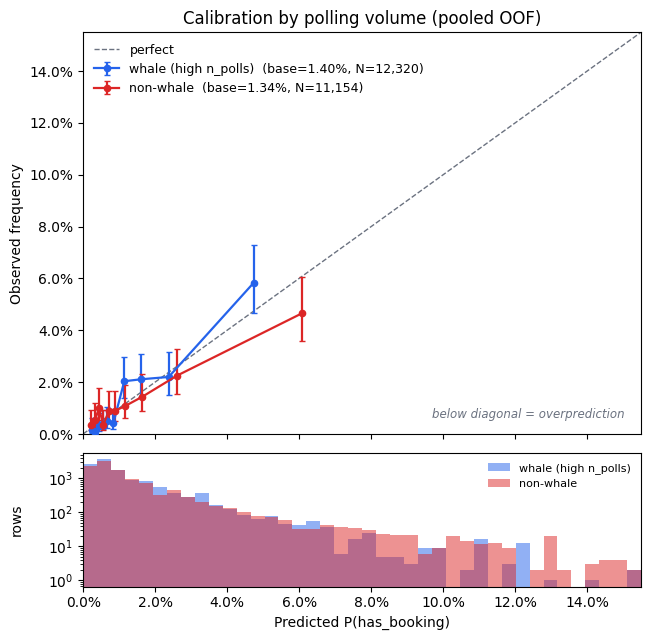

In [21]:
fig = plot_calibration_by_volume(oof_cal,y_train,whales_pt_mask_train);
fig.savefig(REPORTS_FIGURE/"oof_cali.png")

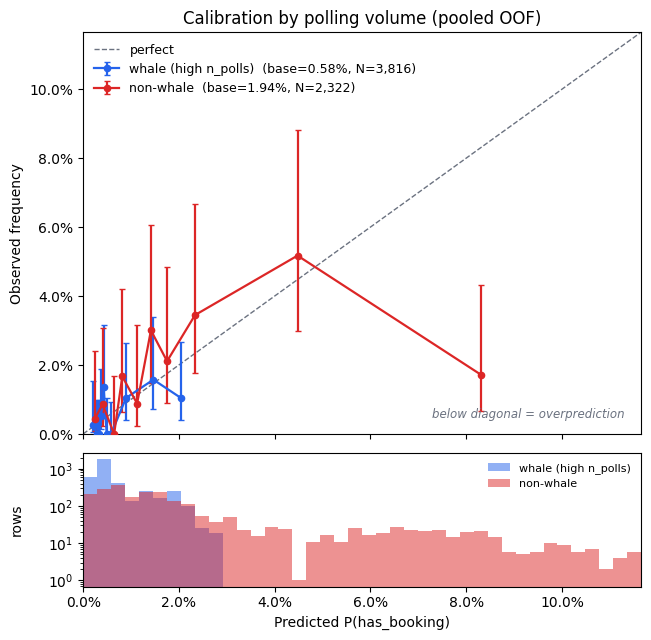

In [22]:
fig = plot_calibration_by_volume(
    p_cal,
    y_test,
    whales_pt_mask_test
)

fig.savefig(REPORTS_FIGURE/"test_cali.png")

 booking whales: median recall 78%, worst 64%  (n=2)
       the rest: median recall 100%, worst 80%  (n=5)


<Axes: xlabel='whale', ylabel='recall'>

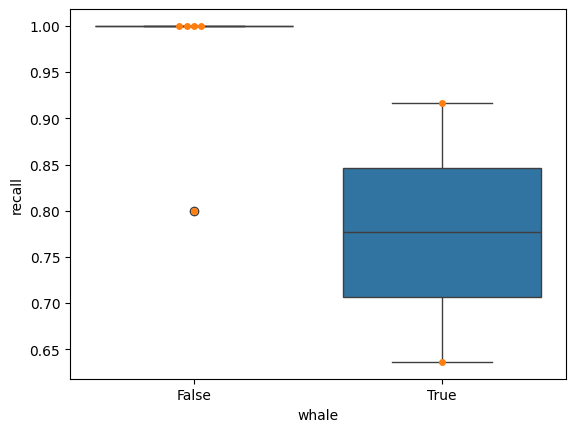

In [23]:
t = per_customer_at_budget(df_test, p_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

 booking whales: median recall 88%, worst 57%  (n=4)
       the rest: median recall 91%, worst 0%  (n=26)


<Axes: xlabel='whale', ylabel='recall'>

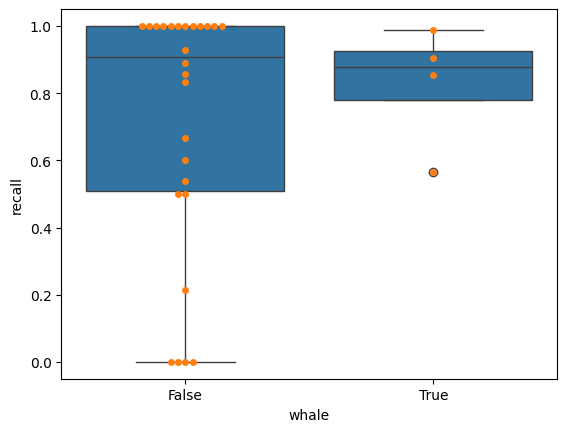

In [24]:

t = per_customer_at_budget(df_train, oof_cal, budget=0.50)
for name, g in [("booking whales", t[t.whale]), ("the rest", t[~t.whale])]:
    print(f"{name:>15}: median recall {g.recall.median():.0%}, "
          f"worst {g.recall.min():.0%}  (n={len(g)})")
sns.boxplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary
sns.swarmplot(data=t,x="whale",y="recall")  # if you want the distribution, not just the summary

90% of bookings for 63% of polls (95% CI 48-79%)


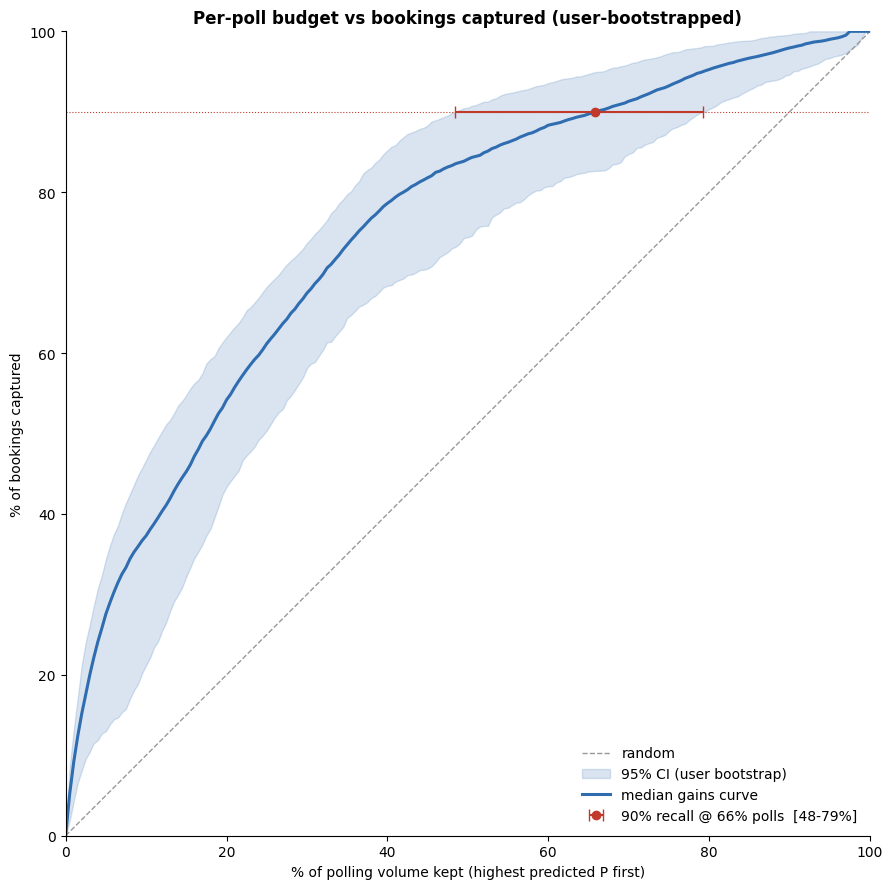

In [25]:
fig, res = bootstrapped_gain_curve(df_train, oof_cal)
fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_oof.png")
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

90% of bookings for 65% of polls (95% CI 54-76%)


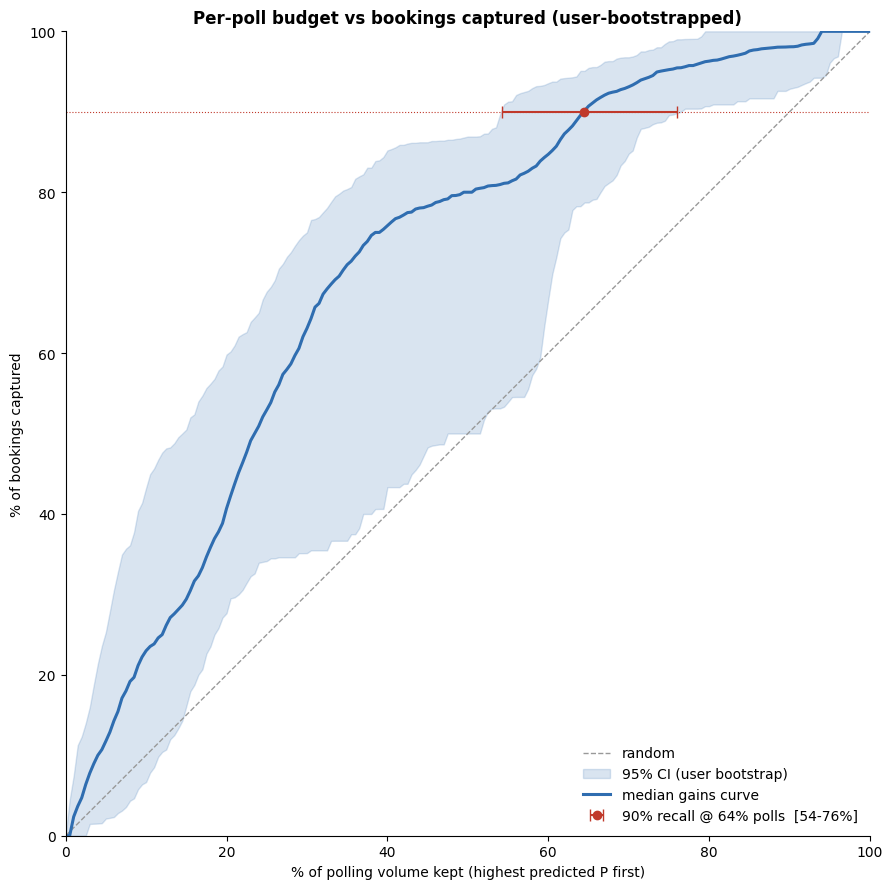

In [26]:
fig, res = bootstrapped_gain_curve(df_test, p_cal)
fig.savefig(REPORTS_FIGURE/"bootstrapped_gain_curve_test.png")
print(f"90% of bookings for {res['budget']*100:.0f}% of polls (95% CI {res['budget_ci'][0]*100:.0f}-{res['budget_ci'][2]*100:.0f}%)")

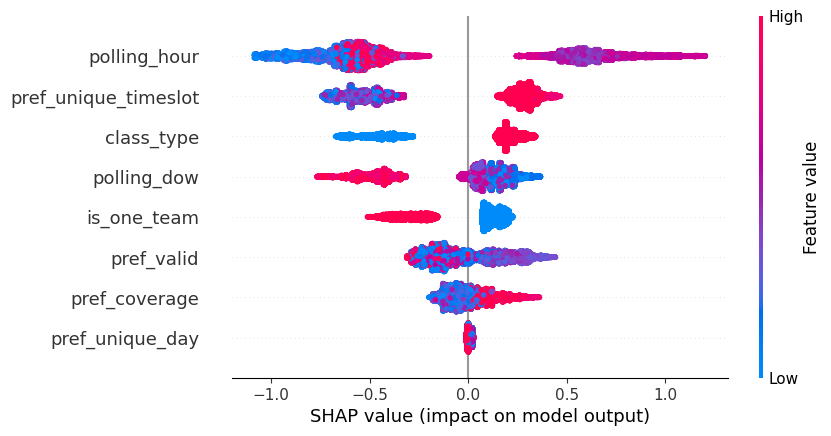

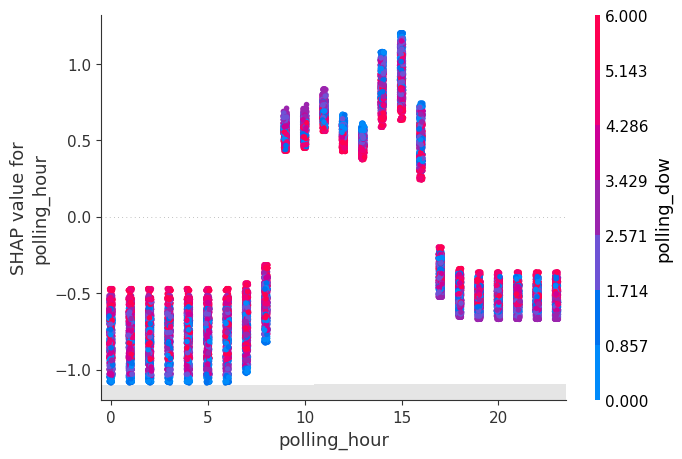

In [30]:
import shap
explainer = shap.TreeExplainer(model.booster)   # raw margin = log-odds
sv = explainer(df_train[FEATS_ABL_LIST[CHOSEN_FEATURES]])                   # X_eval = held-out sample
shap.plots.beeswarm(sv)
shap.plots.scatter(sv[:, "polling_hour"], color=sv[:, "polling_dow"])
# older shap: shap.summary_plot(explainer.shap_values(X_eval), X_eval)